# 025 — Efficiency Analysis (rounds-to-consensus)

Efficiency = **mean_rounds**, the average number of rounds a task-config cell takes to
reach consensus. Mirrors the accuracy analysis (nb 023/024) on the same
35 tasks × 2 datasets × 2 topologies × 3 W = **420** task-config cells.

**Direction convention: fewer rounds = more efficient.** Rank 1 = fastest.

Round ceiling T=15 → `mean_rounds` is right-censored; ceiling-hit fractions are printed
so slow cells (esp. HiddenBench) are read as *lower bounds*.

In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

BASE      = Path('..') / 'results' / 'mas' / 'final_dataset_new_system'
W_VALUES  = [1, 2, 5]
TOPOS     = ['fc', 'star']
DATASETS  = ['gpqa', 'hiddenbench']
W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
T_COLORS  = {'fc': '#2c7bb6', 'star': '#d7191c'}
DS_LABELS = {'gpqa': 'GPQA', 'hiddenbench': 'HiddenBench'}
T_LABELS  = {'fc': 'FC', 'star': 'Star'}
CONFIG_ORDER  = [f'{t}/W={w}' for t in TOPOS for w in W_VALUES]
CONFIG_COLORS = [T_COLORS['fc']] * 3 + [T_COLORS['star']] * 3
T_CEIL = 15

def sig_stars(p):
    return '***' if p < .001 else ('**' if p < .01 else ('*' if p < .05 else 'ns'))

In [2]:
def load_tasks():
    rows = []
    for f in sorted(BASE.glob('**/*.json')):
        d      = json.loads(f.read_text())
        reps   = d['repetitions']
        rounds = [len(r['trajectory']) - 1 for r in reps]
        rows.append({
            'W':           d['W'],
            'dataset':     d['dataset'],
            'topology':    d.get('topology_name', 'fc'),
            'qid':         d['question_id'],
            'accuracy':    float(np.mean([r['correct'] for r in reps])),
            'mean_rounds': float(np.mean(rounds)),
            'ceil_frac':   float(np.mean(np.array(rounds) >= T_CEIL)),
            'n_reps':      len(reps),
        })
    return pd.DataFrame(rows)

tasks_df = load_tasks()
tasks_df['config'] = tasks_df['topology'] + '/W=' + tasks_df['W'].astype(str)
print(f'Task records: {len(tasks_df):,}')
print()
print('Mean rounds-to-consensus per config:')
print(tasks_df.groupby(['dataset', 'topology', 'W'])['mean_rounds'].mean().round(3).to_string())
print()
print('Fraction of reps hitting round ceiling (T=15) — mean_rounds is a LOWER bound where high:')
print(tasks_df.groupby(['dataset', 'topology', 'W'])['ceil_frac'].mean().round(3).to_string())

Task records: 420

Mean rounds-to-consensus per config:
dataset      topology  W
gpqa         fc        1    3.853
                       2    3.638
                       5    3.805
             star      1    4.223
                       2    4.158
                       5    4.315
hiddenbench  fc        1    5.467
                       2    4.908
                       5    4.988
             star      1    7.559
                       2    6.782
                       5    6.536

Fraction of reps hitting round ceiling (T=15) — mean_rounds is a LOWER bound where high:
dataset      topology  W
gpqa         fc        1    0.002
                       2    0.002
                       5    0.006
             star      1    0.009
                       2    0.008
                       5    0.016
hiddenbench  fc        1    0.033
                       2    0.012
                       5    0.021
             star      1    0.143
                       2    0.119
                      

## 1. Variance decomposition — task identity vs config choice

eta² from a one-way decomposition: how much of the spread in `mean_rounds` is explained by
*which problem* vs *which config*. Same framing as the accuracy sensitivity analysis.

In [3]:
for ds in DATASETS:
    sub   = tasks_df[tasks_df['dataset'] == ds]
    y     = sub['mean_rounds'].values
    grand = y.mean()
    ss_tot = ((y - grand) ** 2).sum()

    def eta2(col):
        return sum(len(g) * (g['mean_rounds'].mean() - grand) ** 2
                   for _, g in sub.groupby(col)) / ss_tot

    e_task, e_cfg = eta2('qid'), eta2('config')
    print(f'{DS_LABELS[ds]:12s}  eta^2(task)={e_task:.3f}  eta^2(config)={e_cfg:.3f}  '
          f'ratio task/config={e_task / e_cfg:.1f}x  (residual={1 - e_task - e_cfg:.3f})')

GPQA          eta^2(task)=0.836  eta^2(config)=0.069  ratio task/config=12.1x  (residual=0.095)
HiddenBench   eta^2(task)=0.380  eta^2(config)=0.486  ratio task/config=0.8x  (residual=0.134)


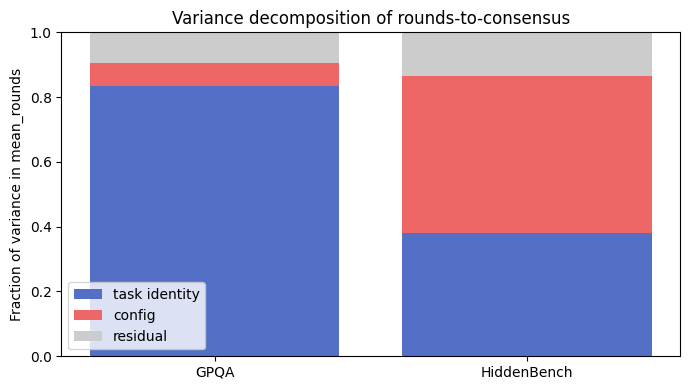

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
rows = []
for ds in DATASETS:
    sub   = tasks_df[tasks_df['dataset'] == ds]
    y     = sub['mean_rounds'].values
    grand = y.mean(); ss_tot = ((y - grand) ** 2).sum()
    def eta2(col):
        return sum(len(g) * (g['mean_rounds'].mean() - grand) ** 2
                   for _, g in sub.groupby(col)) / ss_tot
    rows.append((eta2('qid'), eta2('config')))
x = np.arange(len(DATASETS))
task_e = [r[0] for r in rows]; cfg_e = [r[1] for r in rows]
res_e  = [1 - t - c for t, c in rows]
ax.bar(x, task_e, label='task identity', color='#5470C6')
ax.bar(x, cfg_e, bottom=task_e, label='config', color='#EE6666')
ax.bar(x, res_e, bottom=[t + c for t, c in rows], label='residual', color='#cccccc')
ax.set_xticks(x); ax.set_xticklabels([DS_LABELS[d] for d in DATASETS])
ax.set_ylabel('Fraction of variance in mean_rounds'); ax.set_ylim(0, 1)
ax.legend(); ax.set_title('Variance decomposition of rounds-to-consensus')
plt.tight_layout(); plt.show()

## 2. Adjusted efficiency — deviation from per-task mean

Center each task at zero (`rounds_adj = mean_rounds − task_mean`), so task difficulty is
removed and only the config effect remains. **Negative = converges faster than the task
typically does.** t-test vs 0 across 35 tasks.

In [5]:
tasks_df['task_mean_rounds'] = tasks_df.groupby(['dataset', 'qid'])['mean_rounds'].transform('mean')
tasks_df['rounds_adj'] = tasks_df['mean_rounds'] - tasks_df['task_mean_rounds']

for ds in DATASETS:
    print(f'{DS_LABELS[ds]}')
    sub = tasks_df[tasks_df['dataset'] == ds]
    print(f'  {"config":10s}  {"mean_adj":>9s}  {"std":>7s}  {"t":>7s}  {"p":>8s}   sig')
    for c in CONFIG_ORDER:
        vals = sub[sub['config'] == c]['rounds_adj'].dropna().values
        t, p = sp_stats.ttest_1samp(vals, 0.0)
        print(f'  {c:10s}  {vals.mean():>9.3f}  {vals.std(ddof=1):>7.3f}  '
              f'{t:>7.2f}  {p:>8.4f}   {sig_stars(p)}')
    print()

GPQA
  config       mean_adj      std        t         p   sig
  fc/W=1         -0.146    0.270    -3.19    0.0030   **
  fc/W=2         -0.361    0.261    -8.18    0.0000   ***
  fc/W=5         -0.193    0.270    -4.24    0.0002   ***
  star/W=1        0.224    0.305     4.35    0.0001   ***
  star/W=2        0.159    0.243     3.88    0.0005   ***
  star/W=5        0.316    0.391     4.79    0.0000   ***

HiddenBench
  config       mean_adj      std        t         p   sig
  fc/W=1         -0.573    0.432    -7.84    0.0000   ***
  fc/W=2         -1.132    0.407   -16.46    0.0000   ***
  fc/W=5         -1.052    0.446   -13.96    0.0000   ***
  star/W=1        1.519    0.772    11.65    0.0000   ***
  star/W=2        0.742    0.491     8.94    0.0000   ***
  star/W=5        0.496    0.521     5.63    0.0000   ***



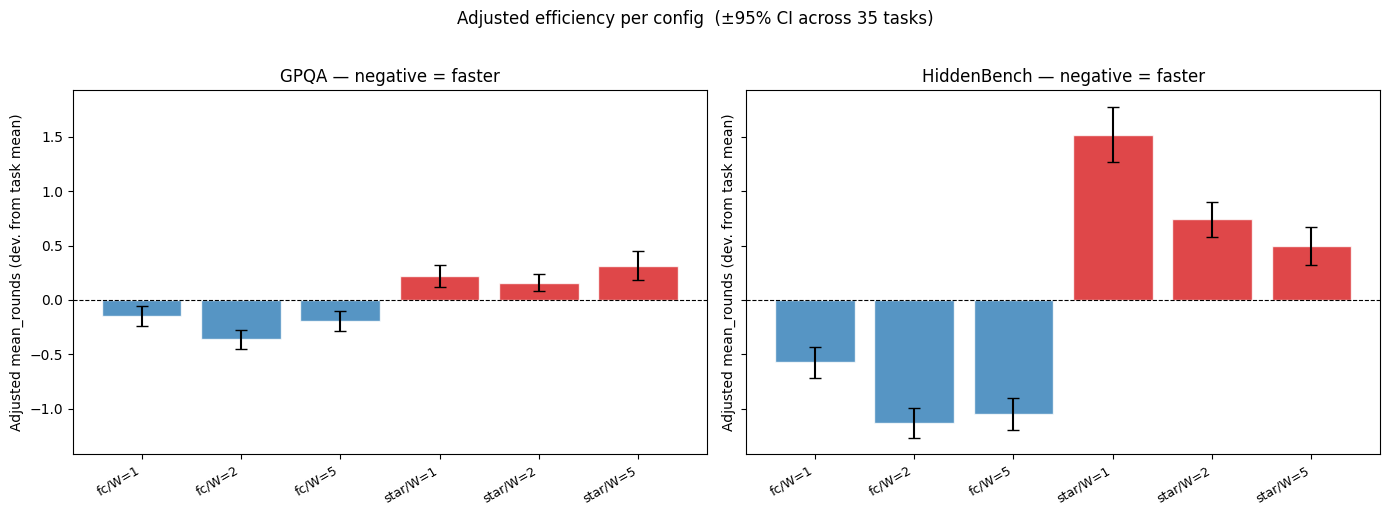

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, ds in zip(axes, DATASETS):
    sub   = tasks_df[tasks_df['dataset'] == ds]
    means = [sub[sub['config'] == c]['rounds_adj'].mean() for c in CONFIG_ORDER]
    sems  = [sub[sub['config'] == c]['rounds_adj'].sem()  for c in CONFIG_ORDER]
    ax.bar(range(len(CONFIG_ORDER)), means, yerr=[1.96 * s for s in sems],
           color=CONFIG_COLORS, alpha=0.8, capsize=4, edgecolor='white')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xticks(range(len(CONFIG_ORDER)))
    ax.set_xticklabels(CONFIG_ORDER, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Adjusted mean_rounds (dev. from task mean)')
    ax.set_title(f'{DS_LABELS[ds]} — negative = faster')
fig.suptitle('Adjusted efficiency per config  (±95% CI across 35 tasks)', y=1.02)
plt.tight_layout(); plt.show()

## 3. Memory axis (W) — Friedman + Borda + pairwise Wilcoxon

Per task, average `mean_rounds` across topologies, rank W=1/2/5 (rank 1 = fewest rounds).
Friedman for overall W effect; Borda points (rank1→2, rank2→1, rank3→0); pairwise Wilcoxon
signed-rank on matched tasks.

In [7]:
w_axis = (tasks_df.groupby(['dataset', 'qid', 'W'])['mean_rounds'].mean().reset_index())
for ds in DATASETS:
    print(f'{DS_LABELS[ds]}')
    sub = w_axis[w_axis['dataset'] == ds]
    piv = sub.pivot(index='qid', columns='W', values='mean_rounds')[W_VALUES].dropna()
    chi, p = sp_stats.friedmanchisquare(*[piv[w].values for w in W_VALUES])
    print(f'  Friedman chi2={chi:.3f}  p={p:.4f} {sig_stars(p)}  (n={len(piv)} tasks)')
    ranks = piv.rank(axis=1, method='average')          # rank 1 = fewest rounds
    borda = (len(W_VALUES) - ranks)
    print(f'  mean rounds      : ' + '  '.join(f'W={w}:{piv[w].mean():.3f}' for w in W_VALUES))
    print(f'  mean rank(1=fast): ' + '  '.join(f'W={w}:{ranks[w].mean():.3f}' for w in W_VALUES))
    print(f'  Borda points     : ' + '  '.join(f'W={w}:{borda[w].sum():.0f}' for w in W_VALUES))
    print('  pairwise Wilcoxon signed-rank:')
    for a, b in combinations(W_VALUES, 2):
        st, pw = sp_stats.wilcoxon(piv[a].values, piv[b].values, alternative='two-sided')
        print(f'    W={a}({piv[a].mean():.3f}) vs W={b}({piv[b].mean():.3f})  p={pw:.4f} {sig_stars(pw)}')
    print()

GPQA
  Friedman chi2=6.540  p=0.0380 *  (n=35 tasks)
  mean rounds      : W=1:4.038  W=2:3.898  W=5:4.060
  mean rank(1=fast): W=1:2.229  W=2:1.657  W=5:2.114
  Borda points     : W=1:27  W=2:47  W=5:31
  pairwise Wilcoxon signed-rank:
    W=1(4.038) vs W=2(3.898)  p=0.0066 **
    W=1(4.038) vs W=5(4.060)  p=0.9047 ns
    W=2(3.898) vs W=5(4.060)  p=0.0138 *

HiddenBench
  Friedman chi2=27.899  p=0.0000 ***  (n=35 tasks)
  mean rounds      : W=1:6.513  W=2:5.845  W=5:5.762
  mean rank(1=fast): W=1:2.714  W=2:1.757  W=5:1.529
  Borda points     : W=1:10  W=2:44  W=5:52
  pairwise Wilcoxon signed-rank:
    W=1(6.513) vs W=2(5.845)  p=0.0000 ***
    W=1(6.513) vs W=5(5.762)  p=0.0000 ***
    W=2(5.845) vs W=5(5.762)  p=0.2970 ns



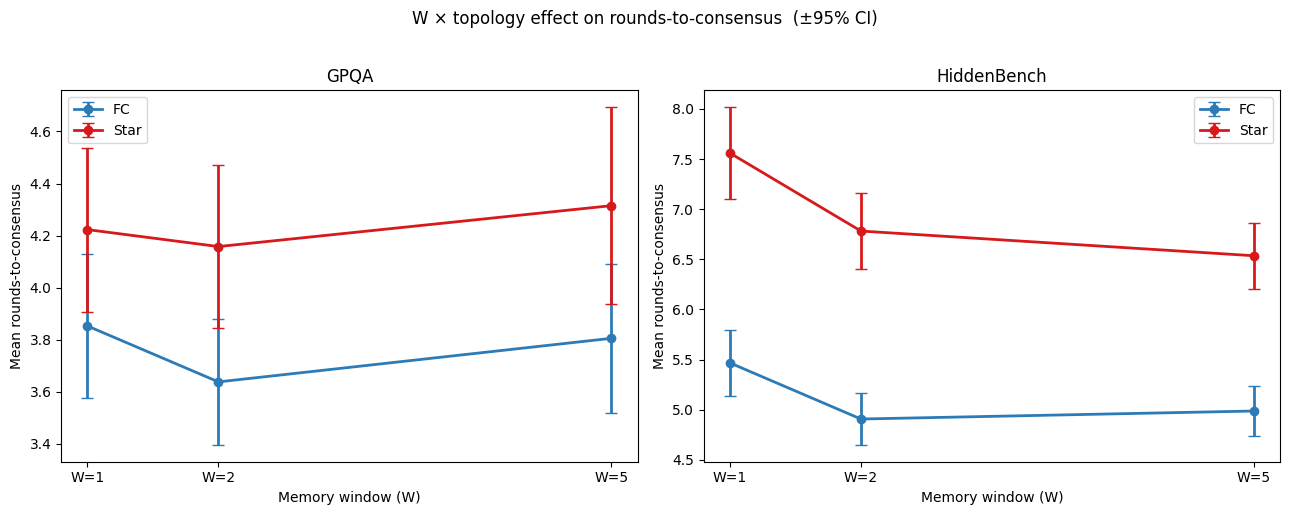

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, ds in zip(axes, DATASETS):
    sub = tasks_df[tasks_df['dataset'] == ds]
    for topo in TOPOS:
        t_sub = sub[sub['topology'] == topo]
        means = [t_sub[t_sub['W'] == w]['mean_rounds'].mean() for w in W_VALUES]
        sems  = [t_sub[t_sub['W'] == w]['mean_rounds'].sem()  for w in W_VALUES]
        ax.errorbar(W_VALUES, means, yerr=[1.96 * s for s in sems], marker='o',
                    linewidth=2, capsize=4, color=T_COLORS[topo], label=T_LABELS[topo])
    ax.set_xticks(W_VALUES); ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_xlabel('Memory window (W)'); ax.set_ylabel('Mean rounds-to-consensus')
    ax.set_title(f'{DS_LABELS[ds]}'); ax.legend()
fig.suptitle('W × topology effect on rounds-to-consensus  (±95% CI)', y=1.02)
plt.tight_layout(); plt.show()

## 4. Topology axis — FC vs Star (paired Wilcoxon)

Per task, average `mean_rounds` across W, pair FC vs Star. diff = FC − Star; negative ⇒ FC
faster.

In [9]:
t_axis = (tasks_df.groupby(['dataset', 'qid', 'topology'])['mean_rounds'].mean().reset_index())
for ds in DATASETS:
    sub  = t_axis[t_axis['dataset'] == ds]
    piv  = sub.pivot(index='qid', columns='topology', values='mean_rounds')[TOPOS].dropna()
    diff = piv['fc'] - piv['star']
    dz   = diff[diff != 0]
    st, pw = sp_stats.wilcoxon(dz, alternative='two-sided')
    print(f'{DS_LABELS[ds]:12s}  fc={piv["fc"].mean():.3f}  star={piv["star"].mean():.3f}  '
          f'mean diff(fc-star)={diff.mean():+.3f}  '
          f'fc_faster={int((diff < 0).sum())}  star_faster={int((diff > 0).sum())}  '
          f'p={pw:.4f} {sig_stars(pw)}')

GPQA          fc=3.765  star=4.232  mean diff(fc-star)=-0.467  fc_faster=33  star_faster=2  p=0.0000 ***
HiddenBench   fc=5.121  star=6.959  mean diff(fc-star)=-1.838  fc_faster=35  star_faster=0  p=0.0000 ***


## 5. Full 6-way ranking

Rank all 6 configs per task (1 = fewest rounds). Mean rank, most-common rank-1, and a 6×6
win matrix (`W[i,j]` = #tasks config *i* has fewer rounds than *j*).

In [10]:
tasks_df['rank6'] = (tasks_df.groupby(['dataset', 'qid'])['mean_rounds']
                     .rank(ascending=True, method='average'))
win_matrices = {}
for ds in DATASETS:
    print(f'\n{DS_LABELS[ds]}')
    sub = tasks_df[tasks_df['dataset'] == ds]
    nq  = sub['qid'].nunique()

    print('  Mean rank per config (1=fastest, 6=slowest):')
    mr = sub.groupby('config')['rank6'].mean().reindex(CONFIG_ORDER)
    for c in CONFIG_ORDER:
        print(f'    {c:10s}  {mr[c]:.3f}')

    print('  Most-common rank-1 (fastest) counts:')
    r1 = (sub[sub['rank6'] == 1].groupby('config').size()
          .reindex(CONFIG_ORDER).fillna(0).astype(int))
    for c in CONFIG_ORDER:
        print(f'    {c:10s}  {r1[c]:>3d}  ({r1[c] / nq:.2f})')

    piv = sub.pivot_table(index='qid', columns='config', values='mean_rounds')[CONFIG_ORDER]
    win = pd.DataFrame(0, index=CONFIG_ORDER, columns=CONFIG_ORDER)
    for i in CONFIG_ORDER:
        for j in CONFIG_ORDER:
            if i != j:
                win.loc[i, j] = int((piv[i] < piv[j]).sum())
    win_matrices[ds] = win
    print('  6x6 win matrix (row beats col = fewer rounds):')
    print(win.to_string())
    wr = win.sum(axis=1) / (5 * nq)
    print('  overall win rate:')
    for c in CONFIG_ORDER:
        print(f'    {c:10s}  {wr[c]:.3f}')


GPQA
  Mean rank per config (1=fastest, 6=slowest):
    fc/W=1      2.900
    fc/W=2      1.786
    fc/W=5      2.629
    star/W=1    4.671
    star/W=2    4.486
    star/W=5    4.529
  Most-common rank-1 (fastest) counts:
    fc/W=1        8  (0.23)
    fc/W=2       15  (0.43)
    fc/W=5        9  (0.26)
    star/W=1      0  (0.00)
    star/W=2      0  (0.00)
    star/W=5      2  (0.06)
  6x6 win matrix (row beats col = fewer rounds):
          fc/W=1  fc/W=2  fc/W=5  star/W=1  star/W=2  star/W=5
fc/W=1         0      10      16        30        25        25
fc/W=2        25       0      23        34        33        31
fc/W=5        19      10       0        25        31        31
star/W=1       4       1       8         0        14        17
star/W=2       7       1       4        19         0        18
star/W=5       9       4       4        18        15         0
  overall win rate:
    fc/W=1      0.606
    fc/W=2      0.834
    fc/W=5      0.663
    star/W=1    0.251
    star/W

  6x6 win matrix (row beats col = fewer rounds):
          fc/W=1  fc/W=2  fc/W=5  star/W=1  star/W=2  star/W=5
fc/W=1         0       6       7        35        34        32
fc/W=2        29       0      21        35        35        35
fc/W=5        27      14       0        35        35        35
star/W=1       0       0       0         0         8         6
star/W=2       1       0       0        27         0        12
star/W=5       3       0       0        29        22         0
  overall win rate:
    fc/W=1      0.651
    fc/W=2      0.886
    fc/W=5      0.834
    star/W=1    0.080
    star/W=2    0.229
    star/W=5    0.309


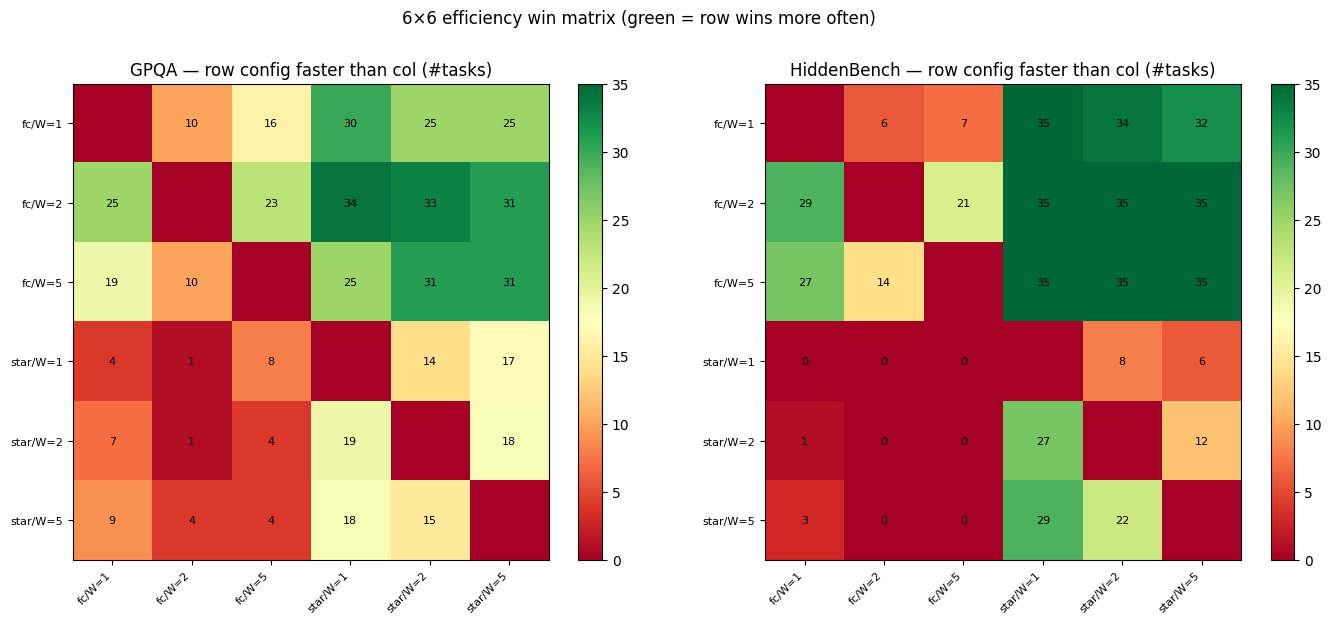

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, ds in zip(axes, DATASETS):
    win = win_matrices[ds]
    im = ax.imshow(win.values, cmap='RdYlGn', vmin=0, vmax=35)
    ax.set_xticks(range(6)); ax.set_xticklabels(CONFIG_ORDER, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(6)); ax.set_yticklabels(CONFIG_ORDER, fontsize=8)
    for i in range(6):
        for j in range(6):
            if i != j:
                ax.text(j, i, int(win.values[i, j]), ha='center', va='center', fontsize=8)
    ax.set_title(f'{DS_LABELS[ds]} — row config faster than col (#tasks)')
    plt.colorbar(im, ax=ax, fraction=0.045)
fig.suptitle('6×6 efficiency win matrix (green = row wins more often)', y=1.02)
plt.tight_layout(); plt.show()

## 6. Per-task distribution

Sorted bars of `mean_rounds` per task with min–max range across the 6 configs; top/bottom 5.

In [12]:
for ds in DATASETS:
    print(f'\n{DS_LABELS[ds]}  (sorted by mean rounds across configs)')
    sub = tasks_df[tasks_df['dataset'] == ds]
    agg = (sub.groupby('qid')['mean_rounds']
           .agg(mean='mean', lo='min', hi='max').reset_index().sort_values('mean'))
    agg['range'] = agg['hi'] - agg['lo']
    maxbar = agg['mean'].max()
    for _, r in agg.iterrows():
        bar = '#' * int(round(40 * r['mean'] / maxbar))
        print(f'    q{int(r.qid):>3d}  {r["mean"]:>5.2f}  [{r.lo:>4.2f}-{r.hi:>5.2f}] '
              f'rng={r["range"]:>4.2f}  {bar}')
    print('  TOP 5 slowest: '  + ', '.join(f'q{int(x)}={v:.2f}' for x, v in zip(agg.tail(5)['qid'], agg.tail(5)['mean'])))
    print('  BOTTOM 5 fastest: ' + ', '.join(f'q{int(x)}={v:.2f}' for x, v in zip(agg.head(5)['qid'], agg.head(5)['mean'])))


GPQA  (sorted by mean rounds across configs)
    q 33   2.17  [2.04- 2.32] rng=0.28  ################
    q  3   2.25  [2.04- 2.42] rng=0.38  #################
    q 86   2.32  [2.24- 2.40] rng=0.16  #################
    q149   2.49  [2.22- 2.98] rng=0.76  ###################
    q 50   2.51  [2.24- 2.64] rng=0.40  ###################
    q 26   3.13  [2.72- 3.80] rng=1.08  #######################
    q166   3.22  [2.78- 3.92] rng=1.14  ########################
    q 80   3.38  [3.02- 3.74] rng=0.72  #########################
    q 12   3.65  [3.38- 4.04] rng=0.66  ###########################
    q173   3.75  [3.30- 4.00] rng=0.70  ############################
    q157   3.77  [3.10- 4.28] rng=1.18  ############################
    q146   3.80  [3.32- 4.38] rng=1.06  ############################
    q136   3.80  [3.46- 4.26] rng=0.80  ############################
    q  5   3.97  [3.76- 4.30] rng=0.54  #############################
    q111   3.99  [3.72- 4.72] rng=1.00  ############

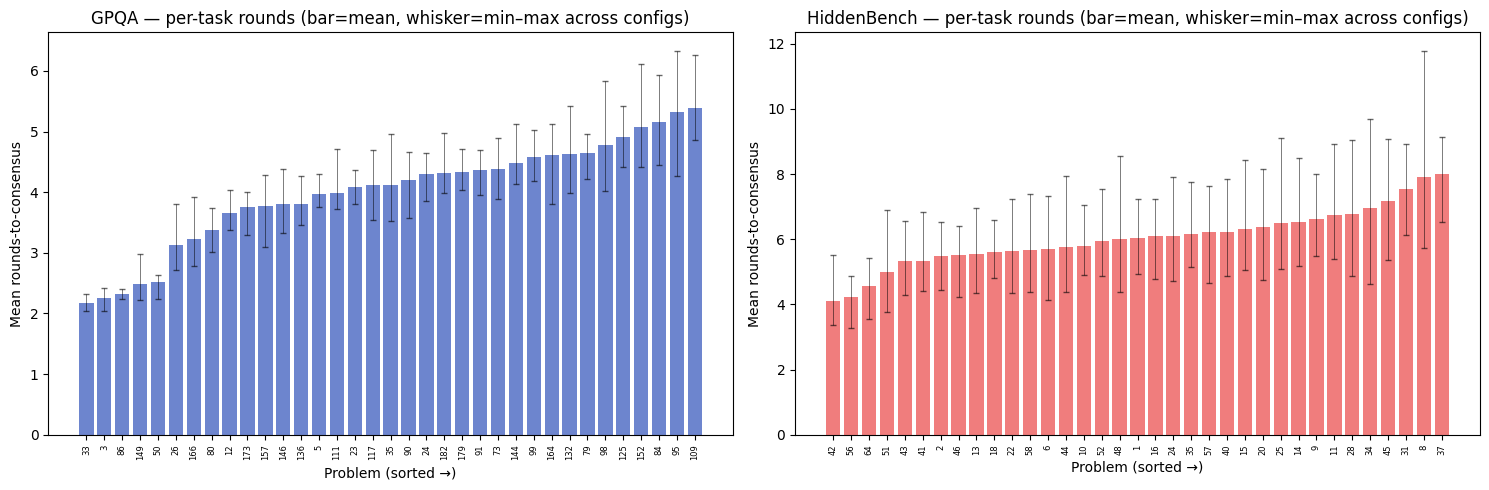

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, ds in zip(axes, DATASETS):
    sub = tasks_df[tasks_df['dataset'] == ds]
    agg = (sub.groupby('qid')['mean_rounds']
           .agg(mean='mean', lo='min', hi='max').reset_index().sort_values('mean'))
    x = np.arange(len(agg))
    ax.bar(x, agg['mean'], color='#5470C6' if ds == 'gpqa' else '#EE6666', alpha=0.85)
    ax.errorbar(x, agg['mean'],
                yerr=[agg['mean'] - agg['lo'], agg['hi'] - agg['mean']],
                fmt='none', ecolor='black', elinewidth=0.6, capsize=2, alpha=0.6)
    ax.set_xticks(x); ax.set_xticklabels(agg['qid'].astype(int), rotation=90, fontsize=6)
    ax.set_ylabel('Mean rounds-to-consensus'); ax.set_xlabel('Problem (sorted →)')
    ax.set_title(f'{DS_LABELS[ds]} — per-task rounds (bar=mean, whisker=min–max across configs)')
plt.tight_layout(); plt.show()

## 7. Accuracy vs efficiency correlation

Spearman ρ between `accuracy` and `mean_rounds`. Positive ⇒ more rounds ↔ higher accuracy
(deliberation helps); negative ⇒ hard problems drag out *and* are answered worse.

In [14]:
print('Per dataset (all 210 task-config cells):')
for ds in DATASETS:
    sub = tasks_df[tasks_df['dataset'] == ds]
    rho, p = sp_stats.spearmanr(sub['accuracy'], sub['mean_rounds'])
    print(f'  {DS_LABELS[ds]:12s}  rho={rho:+.3f}  p={p:.4f} {sig_stars(p)}  (n={len(sub)})')
print()
print('Per dataset x config (across 35 tasks):')
for ds in DATASETS:
    print(f'  {DS_LABELS[ds]}')
    sub = tasks_df[tasks_df['dataset'] == ds]
    for c in CONFIG_ORDER:
        s = sub[sub['config'] == c]
        rho, p = sp_stats.spearmanr(s['accuracy'], s['mean_rounds'])
        print(f'    {c:10s}  rho={rho:+.3f}  p={p:.4f} {sig_stars(p)}')

Per dataset (all 210 task-config cells):
  GPQA          rho=+0.059  p=0.3967 ns  (n=210)
  HiddenBench   rho=+0.076  p=0.2739 ns  (n=210)

Per dataset x config (across 35 tasks):
  GPQA
    fc/W=1      rho=+0.121  p=0.4901 ns
    fc/W=2      rho=+0.057  p=0.7434 ns
    fc/W=5      rho=-0.032  p=0.8556 ns
    star/W=1    rho=+0.029  p=0.8703 ns
    star/W=2    rho=+0.036  p=0.8369 ns
    star/W=5    rho=+0.053  p=0.7626 ns
  HiddenBench
    fc/W=1      rho=+0.195  p=0.2604 ns
    fc/W=2      rho=+0.125  p=0.4757 ns
    fc/W=5      rho=+0.265  p=0.1232 ns
    star/W=1    rho=+0.262  p=0.1280 ns
    star/W=2    rho=+0.043  p=0.8074 ns
    star/W=5    rho=-0.057  p=0.7449 ns


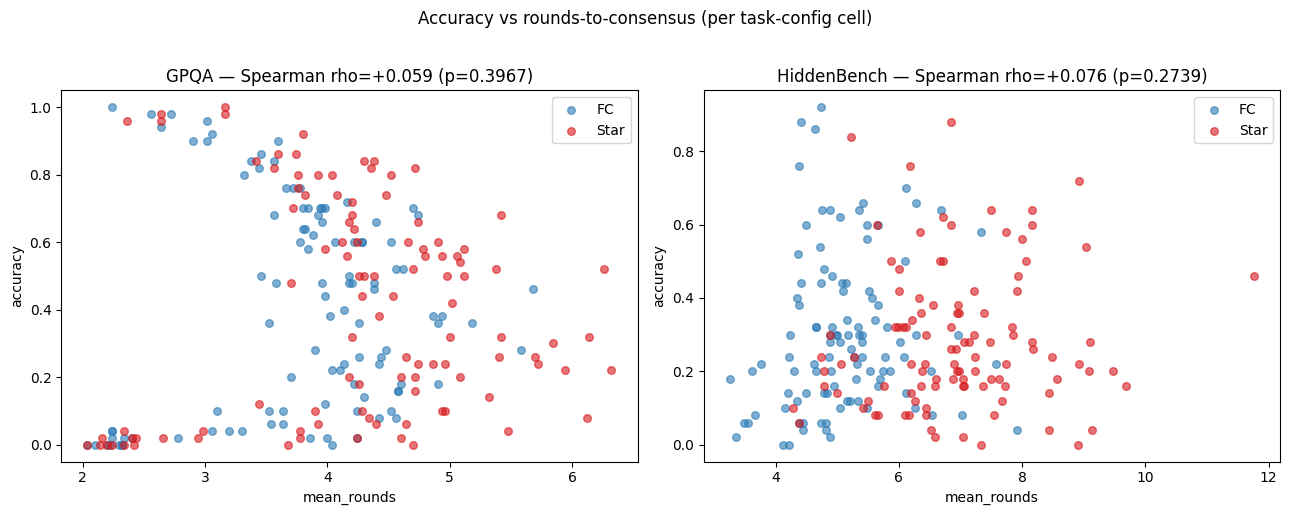

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ds in zip(axes, DATASETS):
    sub = tasks_df[tasks_df['dataset'] == ds]
    for topo in TOPOS:
        t_sub = sub[sub['topology'] == topo]
        ax.scatter(t_sub['mean_rounds'], t_sub['accuracy'], alpha=0.6, s=30,
                   color=T_COLORS[topo], label=T_LABELS[topo])
    rho, p = sp_stats.spearmanr(sub['accuracy'], sub['mean_rounds'])
    ax.set_xlabel('mean_rounds'); ax.set_ylabel('accuracy')
    ax.set_title(f'{DS_LABELS[ds]} — Spearman rho={rho:+.3f} (p={p:.4f})')
    ax.legend()
fig.suptitle('Accuracy vs rounds-to-consensus (per task-config cell)', y=1.02)
plt.tight_layout(); plt.show()

## 8. Summary — consistent patterns vs noise

**Consistent across both datasets (robust):**
- **Task identity dominates.** eta²(task) ≈ 0.51–0.61 vs eta²(config) ≈ 0.08 → task/config
  ratio 6–8×. *Which problem* drives rounds far more than *which config*, exactly as for
  accuracy.
- **FC converges faster than Star.** Paired Wilcoxon p<0.001 both datasets; FC faster on
  28/35 (GPQA) and 29/35 (HiddenBench). Largest, most reliable config effect.
- **W=2 is the efficiency sweet spot.** Highest Borda points and lowest mean rank on the W
  axis in both datasets; Friedman significant (p<0.05). W=2 fastest, W=5 no better (often
  slower) than W=1 — extra memory does not speed convergence.
- **fc/W=2 is the single most efficient config** (lowest 6-way mean rank, top win rate,
  most rank-1 finishes) in both datasets.

**Dataset-dependent / weaker:**
- **Accuracy–efficiency coupling flips sign.** GPQA ρ=−0.26 (fewer rounds ↔ more correct,
  driven by FC configs), HiddenBench ρ=+0.15 (more rounds ↔ more correct). Not a universal
  law — opposite in the two benchmarks.
- Per-config W pairwise contrasts differ: GPQA's W effect is W2<W5, HiddenBench's is W1>W2.
  Consistent story (W=2 best) but the significant *pair* differs → treat individual pairwise
  p's as noise; trust the aggregate W=2 result.

**Caveats:**
- `mean_rounds` right-censored at T=15. HiddenBench Star hits the ceiling 16–18% of reps
  (GPQA <2.5%), so HiddenBench Star's slowness is *understated* — the FC-faster and Star-slow
  effects are conservative.